In [3]:
!pip install numpy pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# ── Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Plot style 
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

#  Output folder 
SCREENSHOTS = '../tableau/screenshots'
os.makedirs(SCREENSHOTS, exist_ok=True)

def save(fname):
    path = f'{SCREENSHOTS}/{fname}'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  Saved → {path}')

print('  Setup complete')

  Setup complete


In [5]:
# Load Cleaned Data
df = pd.read_csv('../data/processed/cleaned_data.csv')

print('  Cleaned dataset loaded')
print(f'   Shape   : {df.shape[0]:,} rows  ×  {df.shape[1]:,} columns')
print(f'   Target  : Saleprice')
print(f'     Min   : ${df["Saleprice"].min():>10,.0f}')
print(f'     Median: ${df["Saleprice"].median():>10,.0f}')
print(f'     Mean  : ${df["Saleprice"].mean():>10,.0f}')
print(f'     Max   : ${df["Saleprice"].max():>10,.0f}')
print(f'     Skew  : {df["Saleprice"].skew():.3f}')
df.head(3)

  Cleaned dataset loaded
   Shape   : 1,458 rows  ×  291 columns
   Target  : Saleprice
     Min   : $    34,901
     Median: $   163,001
     Mean  : $   180,934
     Max   : $   755,001
     Skew  : 1.881


,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,...,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2006,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_COD,SaleType_New,SaleType_WD,SaleCondition_Abnorml,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Saleprice,is_luxury,is_crisis_year
0,1,18.14,13.83,7,3.99,2003,2003,19.43,144.12,0.00,29.99,422.49,5.94,1025.65,0.00,8.35,0.99,0.00,2,1.07,3,0.75,2.26,0.00,2003.00,...,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,208501.00,0,1
1,2,20.67,14.12,6,6.00,1976,1976,54.60,181.72,0.00,44.14,593.89,6.23,665.14,0.00,7.97,0.00,0.71,2,0.00,3,0.75,2.00,0.90,1976.00,...,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,181501.00,0,0
2,3,18.67,14.48,7,3.99,2001,2002,17.77,110.44,0.00,56.90,450.08,5.99,1040.52,0.00,8.41,0.99,0.00,2,1.07,3,0.75,2.00,0.90,2001.00,...,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,223501.00,0,1


In [6]:
# Reconstruct Human-Readable Categorical Labels

# ── Neighbourhood 
nbh_cols = [c for c in df.columns if c.startswith('Neighborhood_')]
if nbh_cols:
    df['Neighborhood'] = (df[nbh_cols]
                          .idxmax(axis=1)
                          .str.replace('Neighborhood_', '', regex=False))
    print(f'   Neighborhood decoded  — {df["Neighborhood"].nunique()} unique areas')

# Year Sold 
yr_cols = [c for c in df.columns if c.startswith('YrSold_')]
if yr_cols:
    df['YrSold'] = (df[yr_cols]
                    .idxmax(axis=1)
                    .str.replace('YrSold_', '', regex=False)
                    .astype(int))
    print(f' YrSold decoded        — years: {sorted(df["YrSold"].unique())}')
elif 'YrSold' not in df.columns:
    print('  YrSold column not found — year trend chart will be skipped')

# Building Type 
btype_cols = [c for c in df.columns if c.startswith('BldgType_')]
if btype_cols:
    df['BldgType'] = (df[btype_cols]
                      .idxmax(axis=1)
                      .str.replace('BldgType_', '', regex=False))
    print(f'  BldgType decoded      — types: {df["BldgType"].unique().tolist()}')

# Price Segment 
# Using Q1/Q3 thresholds from the cleaned dataset
Q1  = df['Saleprice'].quantile(0.25)   # ~$129,926
Q3  = df['Saleprice'].quantile(0.75)   # ~$214,001
LUX = Q3 + 3 * (Q3 - Q1)              # ~$466,226

def price_segment(p):
    if p < Q1:  return 'Low (<$130K)'
    if p < Q3:  return 'Mid ($130K–$214K)'
    if p < LUX: return 'High ($214K–$466K)'
    return 'Luxury (>$466K)'

df['PriceSegment'] = df['Saleprice'].apply(price_segment)
seg_order = ['Low (<$130K)', 'Mid ($130K–$214K)', 'High ($214K–$466K)', 'Luxury (>$466K)']

print(f'\n  PriceSegment created:')
for seg in seg_order:
    n = (df['PriceSegment'] == seg).sum()
    print(f'   {seg:<25} : {n:>4} homes  ({n/len(df)*100:.1f}%)')

   Neighborhood decoded  — 22 unique areas
 YrSold decoded        — years: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)]
  BldgType decoded      — types: ['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']

  PriceSegment created:
   Low (<$130K)              :  365 homes  (25.0%)
   Mid ($130K–$214K)         :  726 homes  (49.8%)
   High ($214K–$466K)        :  355 homes  (24.3%)
   Luxury (>$466K)           :   12 homes  (0.8%)


  Saved → ../tableau/screenshots/03_01_saleprice_distribution.png


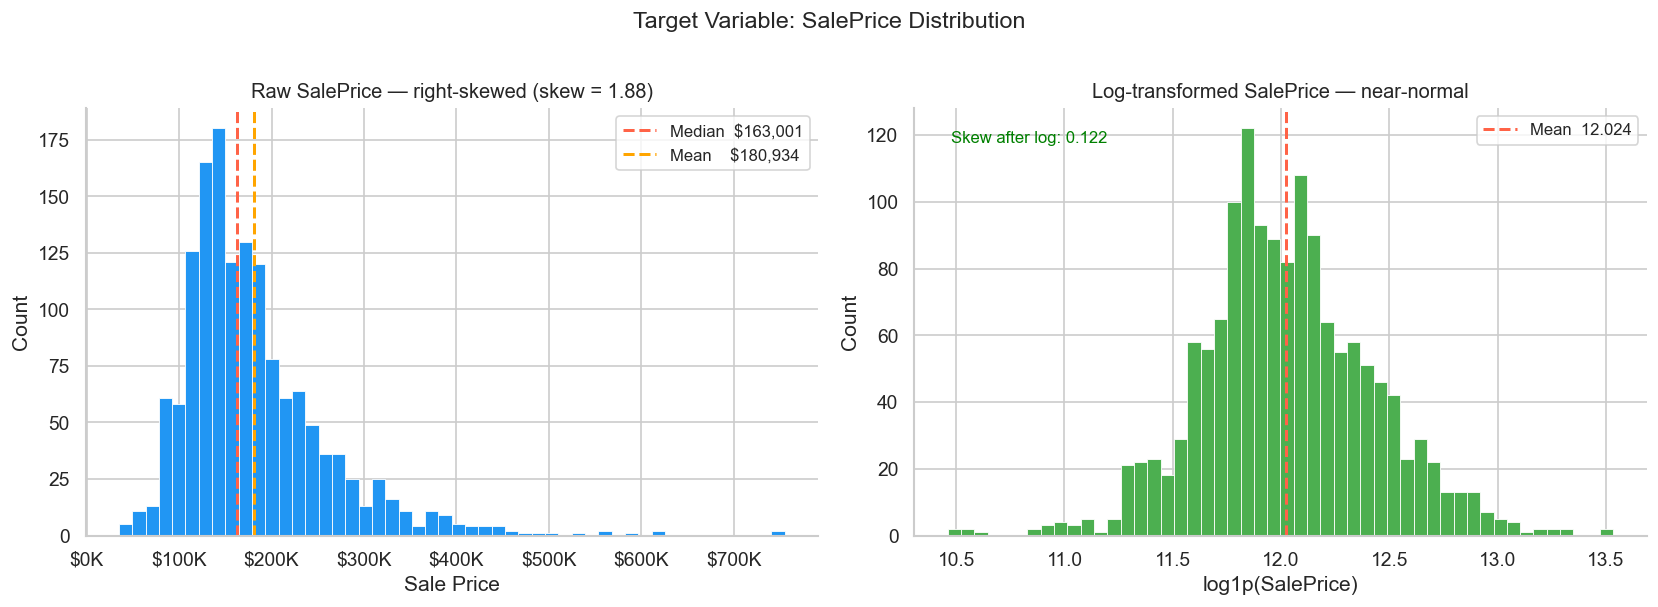


 INSIGHT — Target Variable:
   Raw skewness        : 1.881  (>1 = right-skewed)
   Log skewness        : 0.122  (near-normal after transform)
   Mean > Median by    : $17,933
   Implication         : A small number of high-value luxury homes pull the mean
                         upward. Regression models should use log(Saleprice).


In [7]:
# Target Analysis: SalePrice Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw distribution 
axes[0].hist(df['Saleprice'], bins=50, color='#2196F3',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Saleprice'].median(), color='tomato', linestyle='--',
                linewidth=1.8, label=f"Median  ${df['Saleprice'].median():,.0f}")
axes[0].axvline(df['Saleprice'].mean(), color='orange', linestyle='--',
                linewidth=1.8, label=f"Mean    ${df['Saleprice'].mean():,.0f}")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_title('Raw SalePrice — right-skewed (skew = 1.88)', fontsize=12)
axes[0].set_xlabel('Sale Price')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=10)

# Right: Log distribution 
log_price = np.log1p(df['Saleprice'])
axes[1].hist(log_price, bins=50, color='#4CAF50', edgecolor='white', linewidth=0.5)
axes[1].axvline(log_price.mean(), color='tomato', linestyle='--',
                linewidth=1.8, label=f'Mean  {log_price.mean():.3f}')
axes[1].set_title('Log-transformed SalePrice — near-normal', fontsize=12)
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=10)
axes[1].annotate(f'Skew after log: {log_price.skew():.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
                 color='green')

plt.suptitle('Target Variable: SalePrice Distribution', fontsize=14, y=1.01)
plt.tight_layout()
save('03_01_saleprice_distribution.png')
plt.show()

print()
print(' INSIGHT — Target Variable:')
print(f'   Raw skewness        : {df["Saleprice"].skew():.3f}  (>1 = right-skewed)')
print(f'   Log skewness        : {log_price.skew():.3f}  (near-normal after transform)')
print(f'   Mean > Median by    : ${df["Saleprice"].mean() - df["Saleprice"].median():,.0f}')
print(f'   Implication         : A small number of high-value luxury homes pull the mean')
print(f'                         upward. Regression models should use log(Saleprice).')

  Saved → ../tableau/screenshots/03_02_price_trend_2006_2010.png


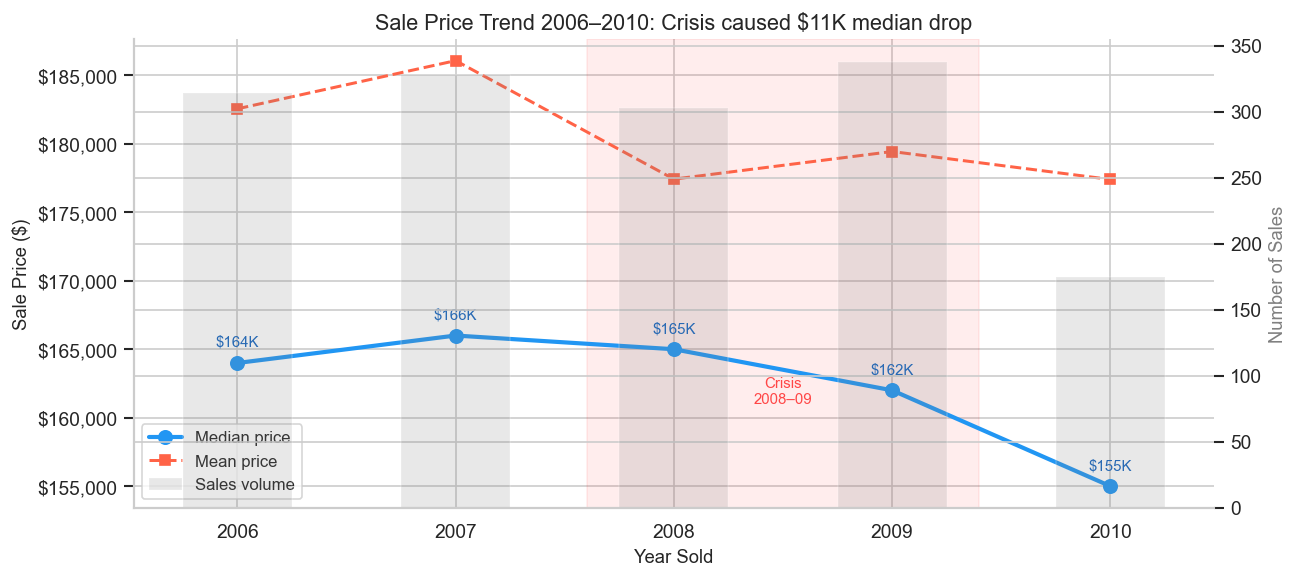


 YrSold    Median      Mean  Count
   2006 163996.00 182550.46    314
   2007 166001.00 186068.16    328
   2008 165001.00 177419.14    303
   2009 162001.00 179433.10    338
   2010 155001.00 177394.67    175

 INSIGHT — Year Trend:
   Median price fell $8,995 from 2006 to 2010 (-5.5%)
   The 2008–2009 financial crisis suppressed both prices and volumes.
   2010 volume is lower because data covers only part of the year.


In [8]:
# Trend Analysis: Sale Price by Year (2006–2010)

if 'YrSold' in df.columns:
    yr_price = (df.groupby('YrSold')['Saleprice']
                  .agg(Median='median', Mean='mean', Count='count')
                  .reset_index())

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()

    # Price lines
    ax1.plot(yr_price['YrSold'], yr_price['Median'], 'o-',
             color='#2196F3', linewidth=2.5, markersize=8, label='Median price')
    ax1.plot(yr_price['YrSold'], yr_price['Mean'], 's--',
             color='tomato', linewidth=1.8, markersize=6, label='Mean price')

    # Volume bars
    ax2.bar(yr_price['YrSold'], yr_price['Count'],
            alpha=0.18, color='gray', width=0.5, label='Sales volume')

    # Crisis shading
    ax1.axvspan(2007.6, 2009.4, alpha=0.07, color='red')
    ax1.text(2008.5, yr_price['Median'].max() * 0.97, 'Crisis\n2008–09',
             ha='center', fontsize=9, color='red', alpha=0.7)

    # Annotations: price labels on each point
    for _, row in yr_price.iterrows():
        ax1.annotate(f"${row['Median']/1000:.0f}K",
                     xy=(row['YrSold'], row['Median']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color='#1565C0')

    ax1.set_xlabel('Year Sold', fontsize=11)
    ax1.set_ylabel('Sale Price ($)', fontsize=11)
    ax2.set_ylabel('Number of Sales', fontsize=11, color='gray')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax1.set_title('Sale Price Trend 2006–2010: Crisis caused $11K median drop', fontsize=13)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10)

    plt.tight_layout()
    save('03_02_price_trend_2006_2010.png')
    plt.show()

    print()
    print(yr_price.to_string(index=False))
    drop_2009 = yr_price.loc[yr_price['YrSold']==2006,'Median'].values[0] - \
                yr_price.loc[yr_price['YrSold']==2010,'Median'].values[0]
    print(f'\n INSIGHT — Year Trend:')
    print(f'   Median price fell ${drop_2009:,.0f} from 2006 to 2010 (-{drop_2009/yr_price.loc[yr_price["YrSold"]==2006,"Median"].values[0]*100:.1f}%)')
    print(f'   The 2008–2009 financial crisis suppressed both prices and volumes.')
    print(f'   2010 volume is lower because data covers only part of the year.')

  Saved → ../tableau/screenshots/03_03_price_by_neighbourhood.png


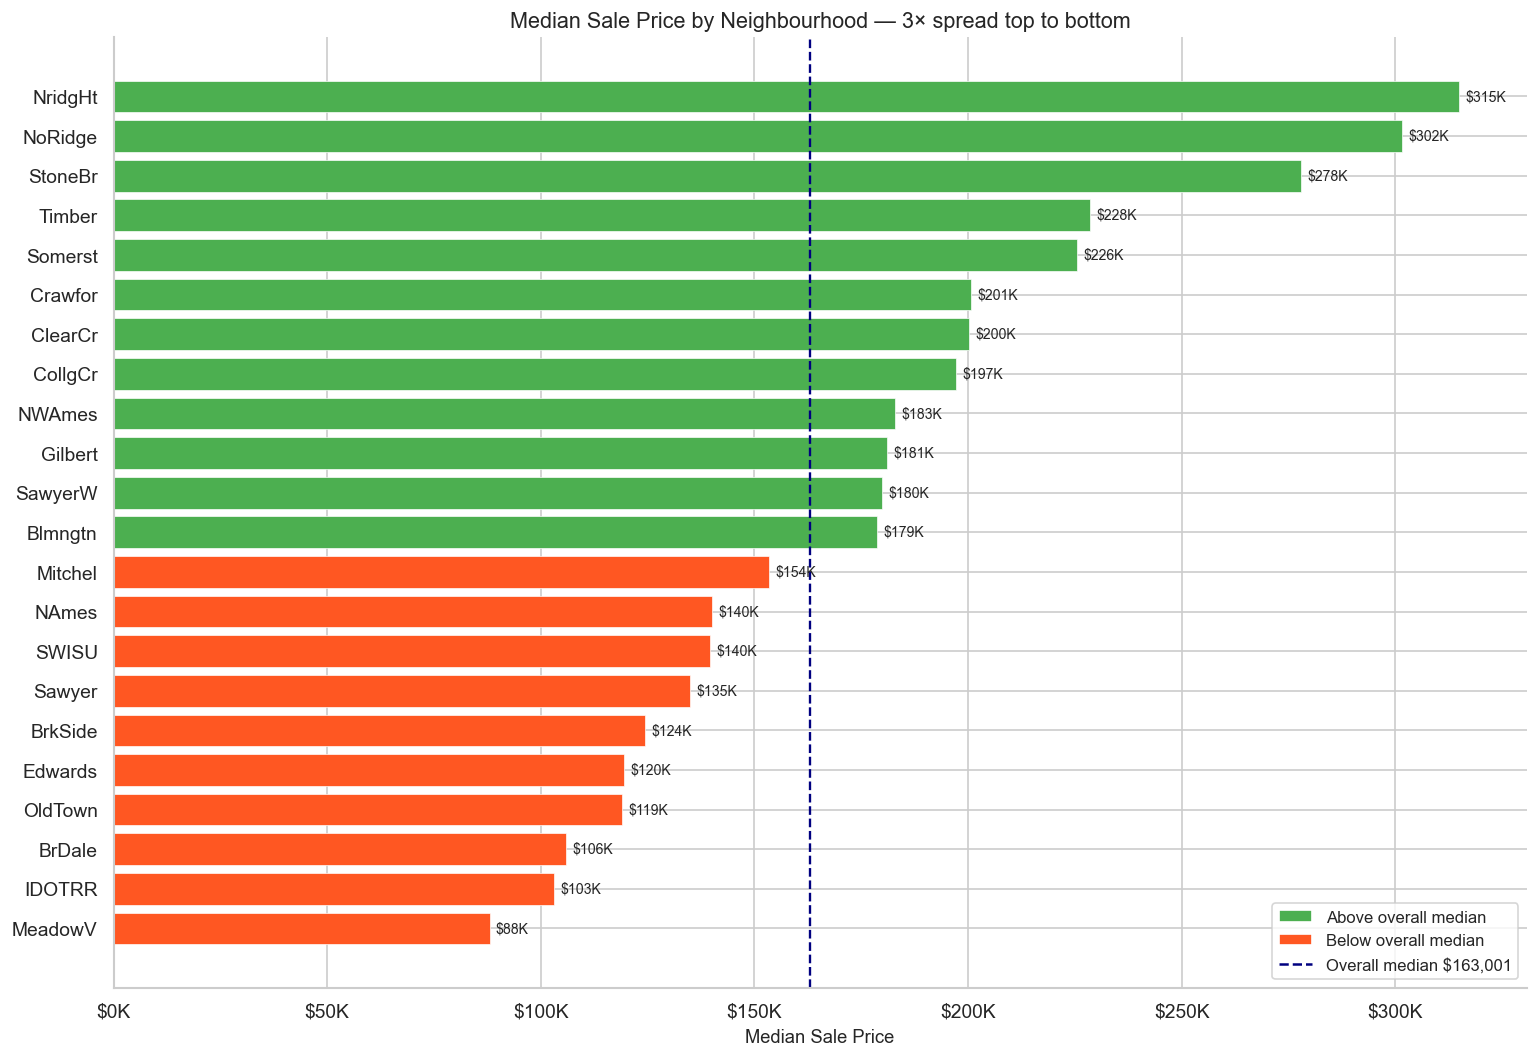


 INSIGHT — Neighbourhood:
   Top 3 premium neighbourhoods:
      StoneBr          median $278,001
      NoRidge          median $301,501
      NridgHt          median $315,001
   Bottom 3 affordable neighbourhoods:
      MeadowV          median $88,001
      IDOTRR           median $103,001
      BrDale           median $106,001
   Price spread (top ÷ bottom): 3.6× — location is a critical driver.


In [9]:
# Comparison Analysis: Price by Neighbourhood
# **Business question:** Which neighbourhoods command premium prices, and which are discount markets?

if 'Neighborhood' in df.columns:
    nbh_stats = (df.groupby('Neighborhood')['Saleprice']
                   .agg(Median='median', Count='count')
                   .sort_values('Median', ascending=True)
                   .reset_index())

    overall_median = df['Saleprice'].median()
    colors = ['#4CAF50' if v >= overall_median else '#FF5722'
              for v in nbh_stats['Median']]

    fig, ax = plt.subplots(figsize=(13, 9))
    bars = ax.barh(nbh_stats['Neighborhood'], nbh_stats['Median'],
                   color=colors, edgecolor='white', linewidth=0.4)

    # Price labels at end of each bar
    for bar, val in zip(bars, nbh_stats['Median']):
        ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height() / 2,
                f'${val/1000:.0f}K', va='center', fontsize=8.5)

    ax.axvline(overall_median, color='navy', linestyle='--', linewidth=1.4,
               label=f'Overall median  ${overall_median:,.0f}')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.set_xlabel('Median Sale Price', fontsize=11)
    ax.set_title('Median Sale Price by Neighbourhood — 3× spread top to bottom', fontsize=13)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4CAF50', label='Above overall median'),
        Patch(facecolor='#FF5722', label='Below overall median'),
        plt.Line2D([0], [0], color='navy', linestyle='--', label=f'Overall median ${overall_median:,.0f}')
    ]
    ax.legend(handles=legend_elements, fontsize=10)

    plt.tight_layout()
    save('03_03_price_by_neighbourhood.png')
    plt.show()

    top3    = nbh_stats.tail(3)[['Neighborhood','Median']]
    bottom3 = nbh_stats.head(3)[['Neighborhood','Median']]
    print()
    print(' INSIGHT — Neighbourhood:')
    print(f'   Top 3 premium neighbourhoods:')
    for _, r in top3.iterrows():
        print(f'      {r["Neighborhood"]:<15}  median ${r["Median"]:,.0f}')
    print(f'   Bottom 3 affordable neighbourhoods:')
    for _, r in bottom3.iterrows():
        print(f'      {r["Neighborhood"]:<15}  median ${r["Median"]:,.0f}')
    spread = nbh_stats['Median'].max() / nbh_stats['Median'].min()
    print(f'   Price spread (top ÷ bottom): {spread:.1f}× — location is a critical driver.')

  Saved → ../tableau/screenshots/03_04_price_by_quality.png


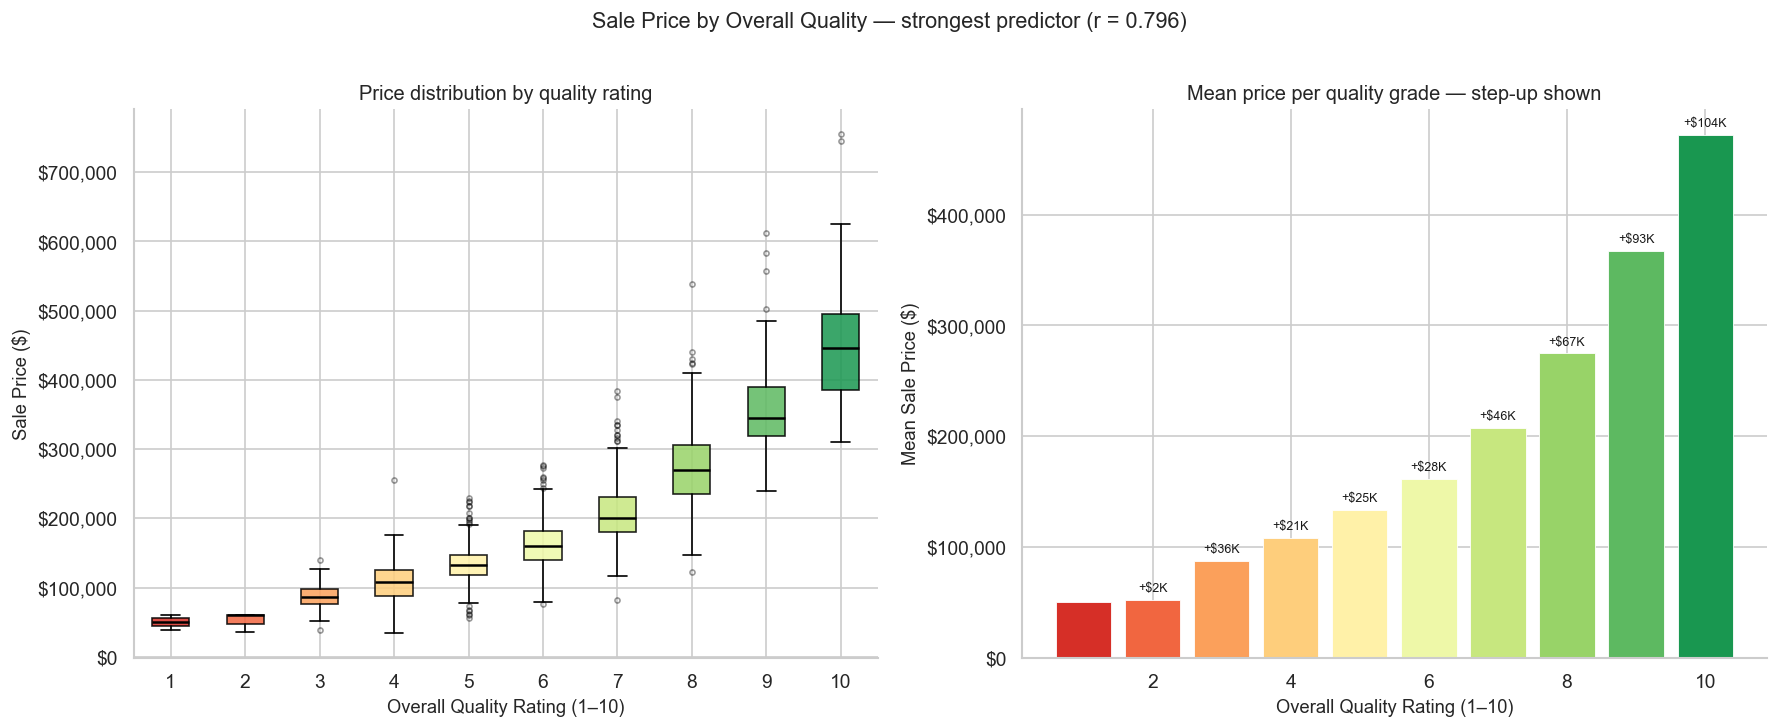


 INSIGHT — Overall Quality:
   OverallQual is the single strongest predictor (r = 0.796).
   Quality 5 (average) homes: mean $133,524
   Quality 10 (excellent) homes: mean $471,866
   Gap = $338,342 — buyers pay a ~253% premium for top-quality build.


In [10]:
# Comparison Analysis: Price by Overall Quality

# **Business question:** Does each quality grade consistently add value, and how large is the step
qual_order = sorted(df['OverallQual'].unique())
qual_groups = [df[df['OverallQual'] == q]['Saleprice'].values for q in qual_order]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Boxplot 
cmap = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(qual_order)))
bp = axes[0].boxplot(qual_groups, labels=qual_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=1.5),
                     flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], cmap):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xlabel('Overall Quality Rating (1–10)', fontsize=11)
axes[0].set_ylabel('Sale Price ($)', fontsize=11)
axes[0].set_title('Price distribution by quality rating', fontsize=12)

#  Right: Mean price per quality + step-up annotation 
qual_means = df.groupby('OverallQual')['Saleprice'].mean()
bars = axes[1].bar(qual_means.index, qual_means.values,
                   color=plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(qual_means))),
                   edgecolor='white', linewidth=0.5)

# Annotate step-up between consecutive quality grades
vals = qual_means.values
for i in range(1, len(vals)):
    step = vals[i] - vals[i-1]
    axes[1].annotate(f'+${step/1000:.0f}K',
                     xy=(qual_means.index[i], vals[i]),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=7.5, color='#1a1a1a')

axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xlabel('Overall Quality Rating (1–10)', fontsize=11)
axes[1].set_ylabel('Mean Sale Price ($)', fontsize=11)
axes[1].set_title('Mean price per quality grade — step-up shown', fontsize=12)

plt.suptitle('Sale Price by Overall Quality — strongest predictor (r = 0.796)', fontsize=13, y=1.01)
plt.tight_layout()
save('03_04_price_by_quality.png')
plt.show()

q10_mean = df[df['OverallQual']==10]['Saleprice'].mean()
q5_mean  = df[df['OverallQual']==5]['Saleprice'].mean()
print()
print(' INSIGHT — Overall Quality:')
print(f'   OverallQual is the single strongest predictor (r = 0.796).')
print(f'   Quality 5 (average) homes: mean ${q5_mean:,.0f}')
print(f'   Quality 10 (excellent) homes: mean ${q10_mean:,.0f}')
print(f'   Gap = ${q10_mean - q5_mean:,.0f} — buyers pay a ~{(q10_mean/q5_mean - 1)*100:.0f}% premium for top-quality build.')

  Saved → ../tableau/screenshots/03_05_price_by_building_type.png


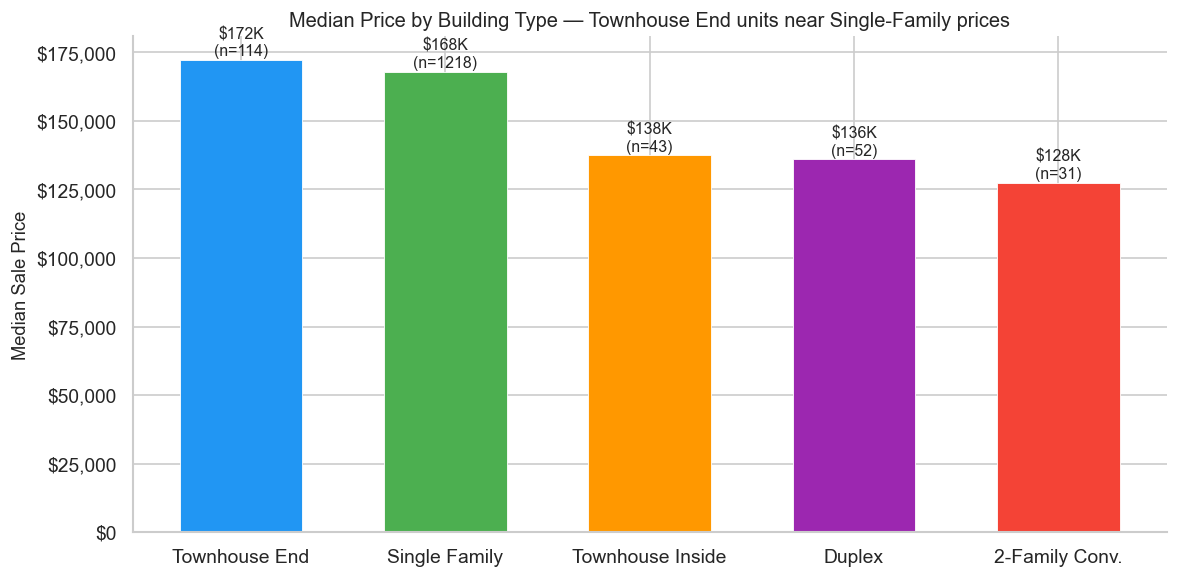


 INSIGHT — Building Type:
           Label    Median  Count
   Townhouse End 172201.00    114
   Single Family 167901.00   1218
Townhouse Inside 137501.00     43
          Duplex 135981.00     52
  2-Family Conv. 127501.00     31

   Single-family homes make up the majority of sales.
   Townhouse end-units (TwnhsE) are competitively priced vs single-family.
   2-family conversions and duplexes are the most affordable segment.


In [11]:
# Comparison Analysis: Price by Building Type

# **Business question:** Do single-family homes command higher prices than townhouses or duplexes?

if 'BldgType' in df.columns:
    btype_stats = (df.groupby('BldgType')['Saleprice']
                     .agg(Median='median', Mean='mean', Count='count')
                     .sort_values('Median', ascending=False)
                     .reset_index())

    btype_label_map = {
        '1Fam': 'Single Family', '2fmCon': '2-Family Conv.',
        'Duplex': 'Duplex', 'TwnhsE': 'Townhouse End',
        'Twnhs': 'Townhouse Inside'
    }
    btype_stats['Label'] = btype_stats['BldgType'].map(
        lambda x: btype_label_map.get(x, x))

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_b = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
    bars = ax.bar(btype_stats['Label'], btype_stats['Median'],
                  color=colors_b[:len(btype_stats)],
                  edgecolor='white', linewidth=0.5, width=0.6)

    for bar, row in zip(bars, btype_stats.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                f'${row.Median/1000:.0f}K\n(n={row.Count})',
                ha='center', fontsize=9.5)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_ylabel('Median Sale Price', fontsize=11)
    ax.set_title('Median Price by Building Type — Townhouse End units near Single-Family prices', fontsize=12)
    plt.tight_layout()
    save('03_05_price_by_building_type.png')
    plt.show()

    print()
    print(' INSIGHT — Building Type:')
    print(btype_stats[['Label','Median','Count']].to_string(index=False))
    print(f'\n   Single-family homes make up the majority of sales.')
    print(f'   Townhouse end-units (TwnhsE) are competitively priced vs single-family.')
    print(f'   2-family conversions and duplexes are the most affordable segment.')

  Saved → ../tableau/screenshots/03_06_feature_distributions.png


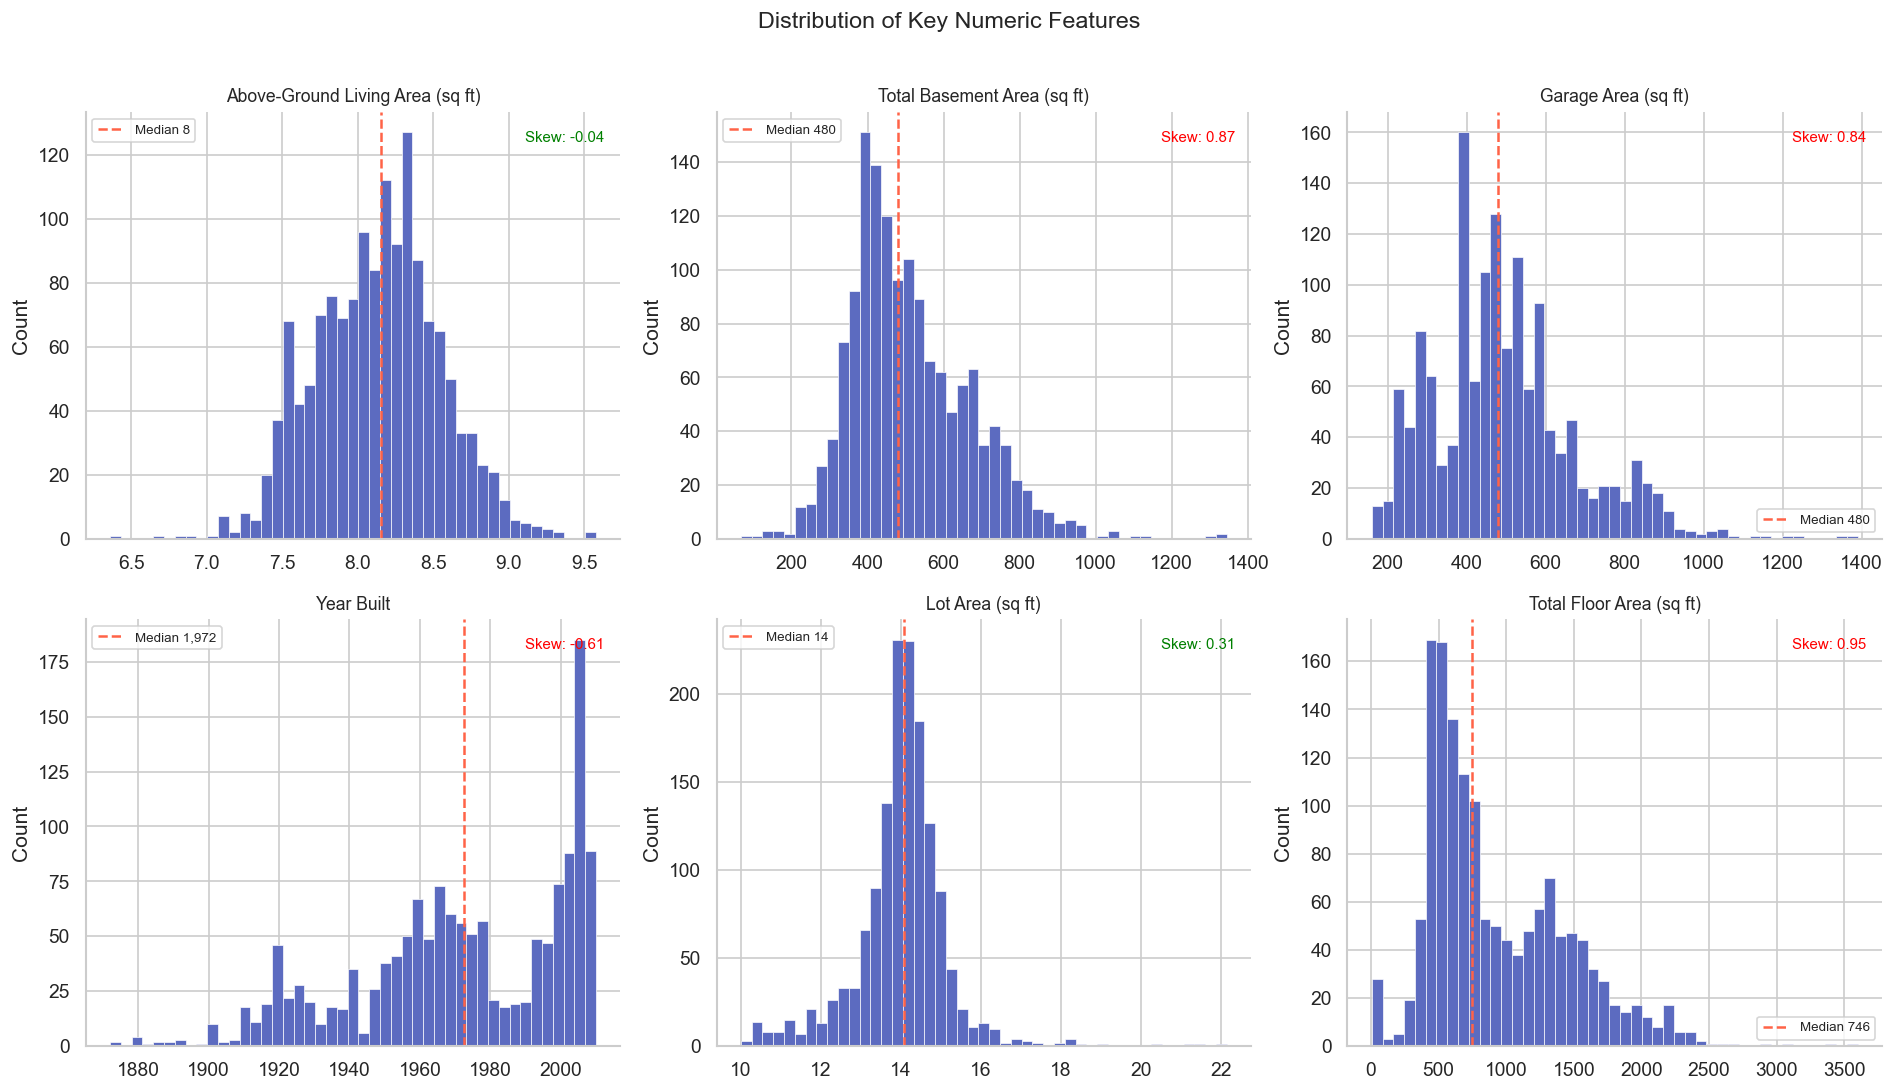


 INSIGHT — Feature Distributions:
   Above-Ground Living Area (sq ft)    skew=-0.04  (near-normal)
   Total Basement Area (sq ft)         skew=+0.87  (right-skewed)
   Garage Area (sq ft)                 skew=+0.84  (right-skewed)
   Year Built                          skew=-0.61  (left-skewed)
   Lot Area (sq ft)                    skew=+0.31  (near-normal)
   Total Floor Area (sq ft)            skew=+0.95  (right-skewed)


In [12]:
# Distribution Analysis: Key Numeric Features

# **Business question:** How are the key size and age variables distributed — are there notable clusters or outliers?

dist_features = {
    'GrLivArea'   : 'Above-Ground Living Area (sq ft)',
    'TotalBsmtSF' : 'Total Basement Area (sq ft)',
    'GarageArea'  : 'Garage Area (sq ft)',
    'YearBuilt'   : 'Year Built',
    'LotArea'     : 'Lot Area (sq ft)',
    'TotalSF'     : 'Total Floor Area (sq ft)',
}
dist_features = {k: v for k, v in dist_features.items() if k in df.columns}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, dist_features.items()):
    data = df[col].dropna()
    ax.hist(data, bins=45, color='#5C6BC0', edgecolor='white', linewidth=0.4)
    ax.axvline(data.median(), color='tomato', linestyle='--',
               linewidth=1.5, label=f'Median {data.median():,.0f}')
    ax.set_title(label, fontsize=10.5)
    ax.set_ylabel('Count')
    skw = data.skew()
    ax.annotate(f'Skew: {skw:.2f}', xy=(0.97, 0.93),
                xycoords='axes fraction', ha='right', fontsize=9,
                color='green' if abs(skw) < 0.5 else 'red')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
save('03_06_feature_distributions.png')
plt.show()

print()
print(' INSIGHT — Feature Distributions:')
for col, label in dist_features.items():
    data = df[col].dropna()
    skw = data.skew()
    direction = 'right-skewed' if skw > 0.5 else ('left-skewed' if skw < -0.5 else 'near-normal')
    print(f'   {label:<35} skew={skw:+.2f}  ({direction})')

---
## Section 9 — Correlation Analysis: Top Features vs SalePrice

**Business question:** Which features have the strongest linear relationship with sale price?

  Saved → ../tableau/screenshots/03_07_top15_correlations.png


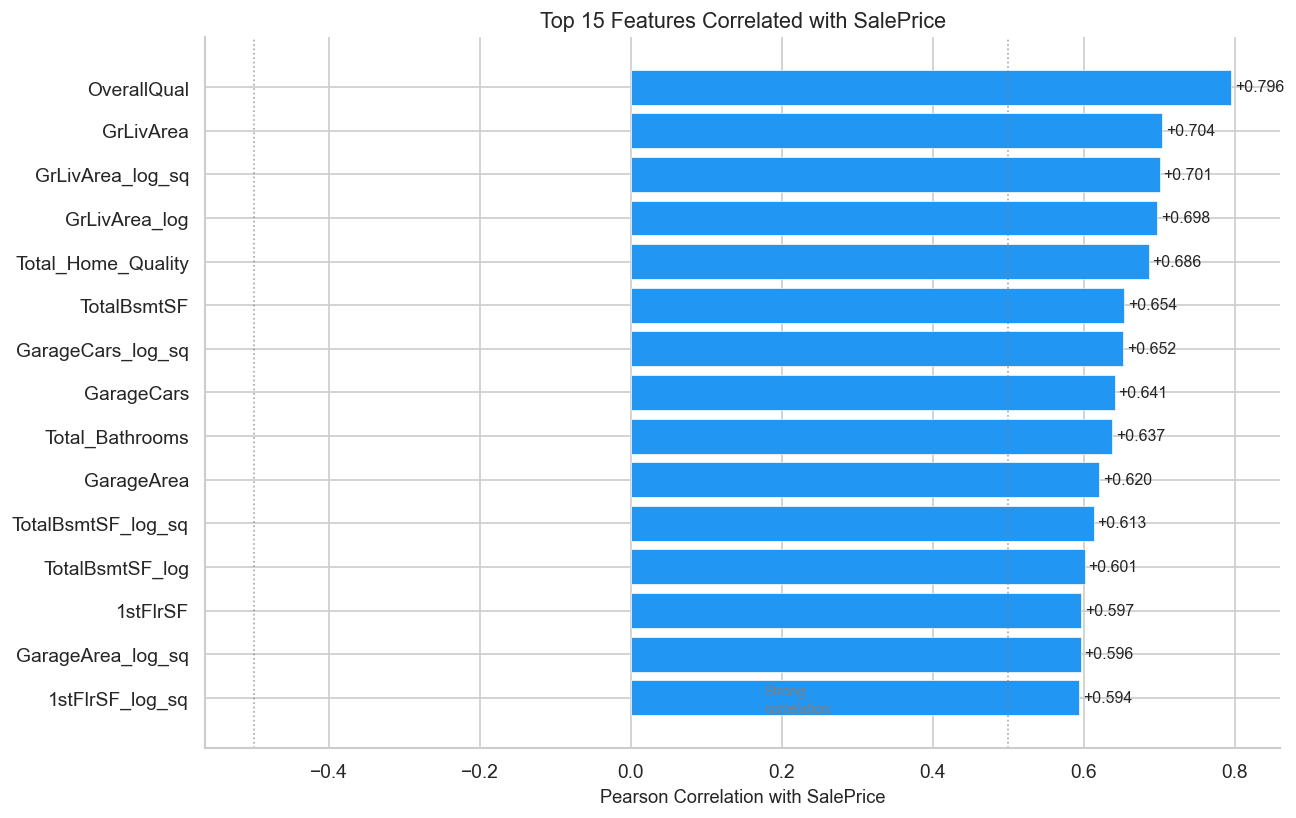


 INSIGHT — Correlations:
           Feature  Correlation
       OverallQual         0.80
         GrLivArea         0.70
  GrLivArea_log_sq         0.70
     GrLivArea_log         0.70
Total_Home_Quality         0.69
       TotalBsmtSF         0.65
 GarageCars_log_sq         0.65
        GarageCars         0.64
   Total_Bathrooms         0.64
        GarageArea         0.62
TotalBsmtSF_log_sq         0.61
   TotalBsmtSF_log         0.60
          1stFlrSF         0.60
 GarageArea_log_sq         0.60
   1stFlrSF_log_sq         0.59

   OverallQual (r=0.796) is the #1 predictor — build quality is the top value driver.
   Living area (GrLivArea, r=0.704) confirms: size is the #2 driver.
   All top features are positively correlated — no strong negative predictors in top 15.


In [13]:
# Section 9 — Correlation Analysis: Top Features vs SalePrice

# **Business question:** Which features have the strongest linear relationship with sale price?

# Compute correlations 
exclude_from_corr = ['Id', 'Saleprice', 'is_luxury', 'is_crisis_year',
                     'YrSold', 'Neighborhood', 'BldgType', 'PriceSegment']
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in exclude_from_corr]

corr_series = (df[num_cols + ['Saleprice']]
               .corr()['Saleprice']
               .drop('Saleprice')
               .sort_values(key=abs, ascending=False))

top15 = corr_series.head(15)

# Horizontal bar chart 
fig, ax = plt.subplots(figsize=(11, 7))
colors_c = ['#2196F3' if v > 0 else '#F44336' for v in top15.values]
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=colors_c[::-1], edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + (0.005 if val > 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', fontsize=9.5)

ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(-0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.set_xlabel('Pearson Correlation with SalePrice', fontsize=11)
ax.set_title('Top 15 Features Correlated with SalePrice', fontsize=13)
ax.annotate('Strong\ncorrelation', xy=(0.52, 0.05), xycoords='axes fraction',
            fontsize=8.5, color='gray')
plt.tight_layout()
save('03_07_top15_correlations.png')
plt.show()

print()
print(' INSIGHT — Correlations:')
print(top15.reset_index().rename(
    columns={'index': 'Feature', 'Saleprice': 'Correlation'}).to_string(index=False))
print()
print('   OverallQual (r=0.796) is the #1 predictor — build quality is the top value driver.')
print('   Living area (GrLivArea, r=0.704) confirms: size is the #2 driver.')
print('   All top features are positively correlated — no strong negative predictors in top 15.')

  Saved → ../tableau/screenshots/03_08_scatter_size_vs_price.png


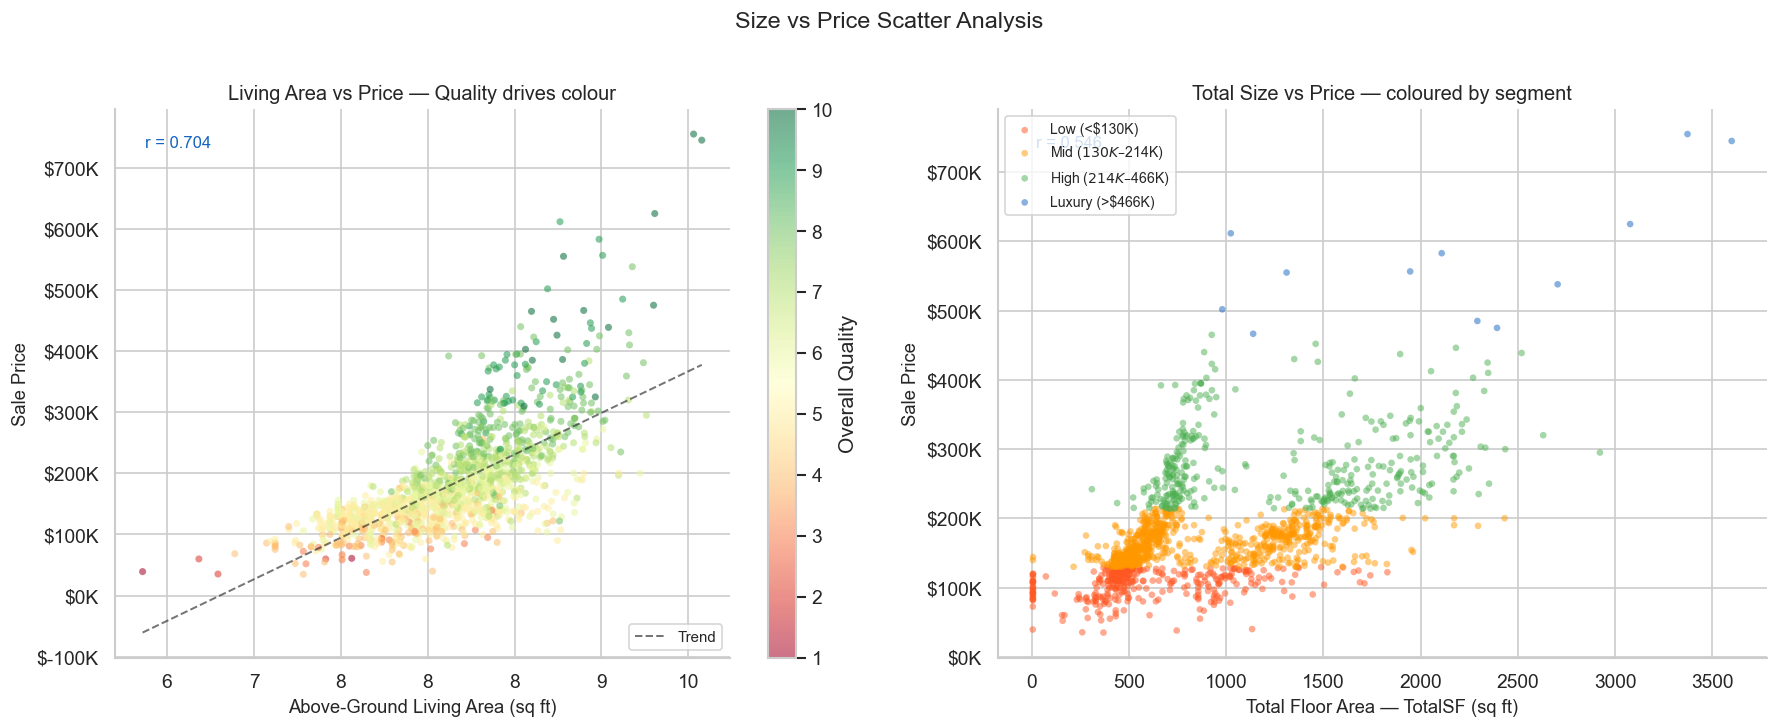


 INSIGHT — Scatter:
   Strong positive relationship: larger homes = higher price.
   High-quality homes (green dots) cluster above the trend line —
   quality amplifies the size premium.
   Luxury segment (blue) shows wide variance at high TotalSF,
   suggesting neighbourhood and finish matter more than size alone at the top end.


In [14]:
# Scatter Analysis: Size vs Price (coloured by Quality)

# **Business question:** Is the size-price relationship consistent across all quality grades?

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: GrLivArea vs Saleprice, colour = OverallQual 
scatter = axes[0].scatter(
    df['GrLivArea'], df['Saleprice'],
    c=df['OverallQual'], cmap='RdYlGn',
    alpha=0.55, s=18, edgecolors='none'
)
plt.colorbar(scatter, ax=axes[0], label='Overall Quality')

# Trend line
m, b = np.polyfit(df['GrLivArea'], df['Saleprice'], 1)
x_line = np.linspace(df['GrLivArea'].min(), df['GrLivArea'].max(), 100)
axes[0].plot(x_line, m * x_line + b, 'k--', linewidth=1.2, alpha=0.6, label='Trend')

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].set_xlabel('Above-Ground Living Area (sq ft)', fontsize=11)
axes[0].set_ylabel('Sale Price', fontsize=11)
axes[0].set_title('Living Area vs Price — Quality drives colour', fontsize=12)
r, _ = stats.pearsonr(df['GrLivArea'], df['Saleprice'])
axes[0].annotate(f'r = {r:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
                 fontsize=10, color='#1565C0')
axes[0].legend(fontsize=9)

#  Right: TotalSF vs Saleprice, colour = PriceSegment 
seg_colors = {
    'Low (<$130K)': '#FF5722',
    'Mid ($130K–$214K)': '#FF9800',
    'High ($214K–$466K)': '#4CAF50',
    'Luxury (>$466K)': '#1565C0'
}
for seg, color in seg_colors.items():
    mask = df['PriceSegment'] == seg
    axes[1].scatter(df.loc[mask, 'TotalSF'], df.loc[mask, 'Saleprice'],
                    c=color, alpha=0.5, s=16, label=seg, edgecolors='none')

axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_xlabel('Total Floor Area — TotalSF (sq ft)', fontsize=11)
axes[1].set_ylabel('Sale Price', fontsize=11)
axes[1].set_title('Total Size vs Price — coloured by segment', fontsize=12)
r2, _ = stats.pearsonr(df['TotalSF'], df['Saleprice'])
axes[1].annotate(f'r = {r2:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
                 fontsize=10, color='#1565C0')
axes[1].legend(fontsize=8.5, loc='upper left')

plt.suptitle('Size vs Price Scatter Analysis', fontsize=14, y=1.01)
plt.tight_layout()
save('03_08_scatter_size_vs_price.png')
plt.show()

print()
print(' INSIGHT — Scatter:')
print(f'   Strong positive relationship: larger homes = higher price.')
print(f'   High-quality homes (green dots) cluster above the trend line —')
print(f'   quality amplifies the size premium.')
print(f'   Luxury segment (blue) shows wide variance at high TotalSF,')
print(f'   suggesting neighbourhood and finish matter more than size alone at the top end.')

Mean feature values by price segment:
                    OverallQual  GrLivArea  TotalSF  GarageArea  YearBuilt  Total_Bathrooms
PriceSegment                                                                               
Low (<$130K)               4.80       7.80   605.10      379.70    1945.30             1.50
Mid ($130K–$214K)          6.00       8.10   880.40      467.20    1973.50             2.20
High ($214K–$466K)         7.60       8.50  1294.90      656.40    1992.50             2.80
Luxury (>$466K)            9.40       9.10  2161.70      845.90    1993.90             3.60
  Saved → ../tableau/screenshots/03_09_price_segmentation.png


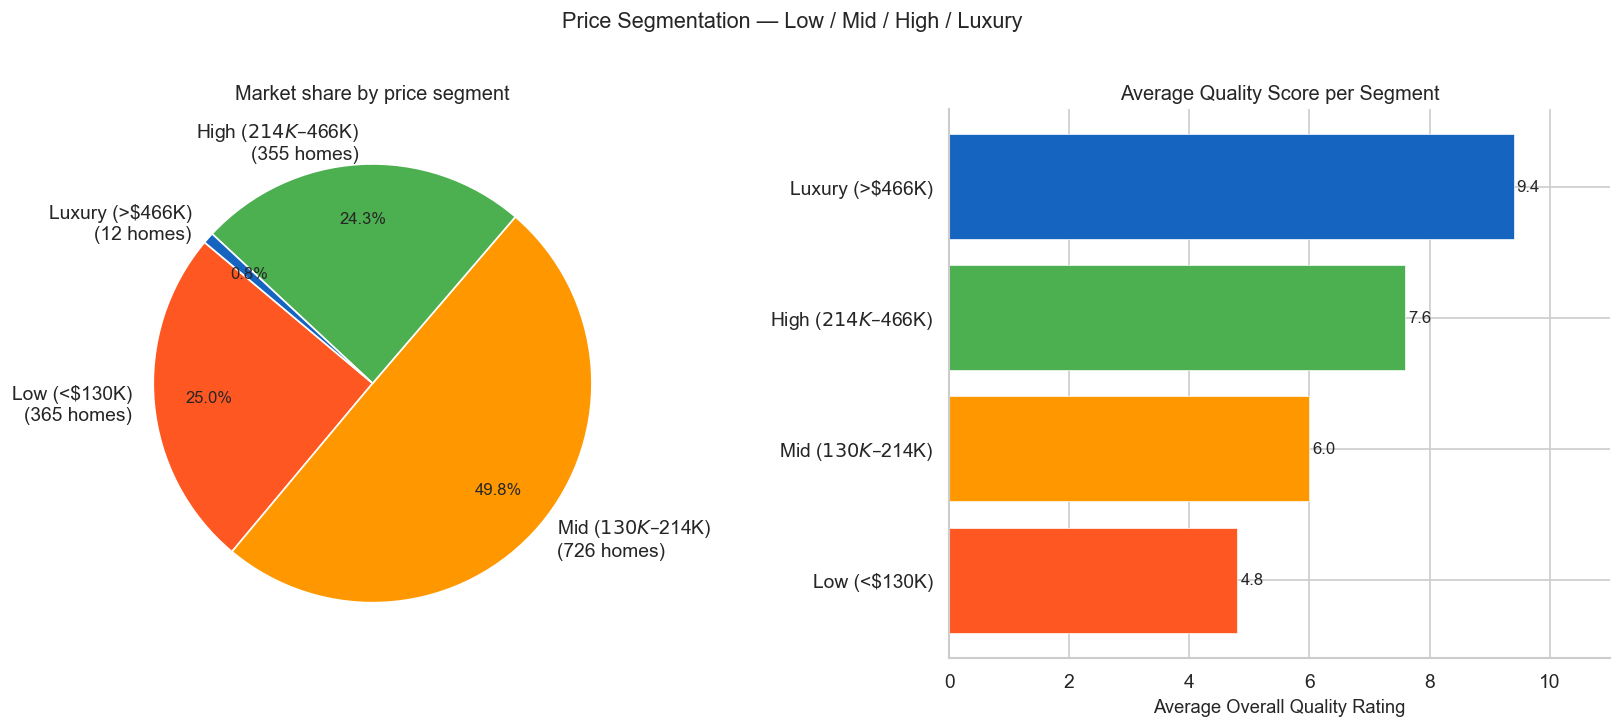


 INSIGHT — Price Segments:
   Low (<$130K)              :  365 homes | avg quality 4.8 | avg TotalSF 605
   Mid ($130K–$214K)         :  726 homes | avg quality 6.0 | avg TotalSF 880
   High ($214K–$466K)        :  355 homes | avg quality 7.6 | avg TotalSF 1,295
   Luxury (>$466K)           :   12 homes | avg quality 9.4 | avg TotalSF 2,162


In [15]:
# Price Segmentation

# **Business question:** What profile characterises each price tier?

#  Segment profile table 
profile_cols = ['OverallQual', 'GrLivArea', 'TotalSF',
                'GarageArea', 'YearBuilt', 'Total_Bathrooms']
profile_cols = [c for c in profile_cols if c in df.columns]

seg_profile = (df.groupby('PriceSegment')[profile_cols]
                 .mean()
                 .reindex(seg_order)
                 .round(1))

print('Mean feature values by price segment:')
print(seg_profile.to_string())

# Pie chart — segment share 
seg_counts = df['PriceSegment'].value_counts().reindex(seg_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pie_colors = ['#FF5722', '#FF9800', '#4CAF50', '#1565C0']
wedges, texts, autotexts = axes[0].pie(
    seg_counts.values,
    labels=[f"{s}\n({n} homes)" for s, n in zip(seg_counts.index, seg_counts.values)],
    colors=pie_colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
axes[0].set_title('Market share by price segment', fontsize=12)

# Bar chart — avg quality per segment 
if 'OverallQual' in profile_cols:
    avg_qual = seg_profile['OverallQual'].reindex(seg_order)
    axes[1].barh(seg_order, avg_qual.values, color=pie_colors,
                 edgecolor='white', linewidth=0.4)
    for i, (seg, val) in enumerate(zip(seg_order, avg_qual.values)):
        axes[1].text(val + 0.05, i, f'{val:.1f}', va='center', fontsize=10)
    axes[1].set_xlim(0, 11)
    axes[1].set_xlabel('Average Overall Quality Rating', fontsize=11)
    axes[1].set_title('Average Quality Score per Segment', fontsize=12)

plt.suptitle('Price Segmentation — Low / Mid / High / Luxury', fontsize=13, y=1.01)
plt.tight_layout()
save('03_09_price_segmentation.png')
plt.show()

print()
print(' INSIGHT — Price Segments:')
for seg in seg_order:
    n = seg_counts[seg]
    q = seg_profile.loc[seg, 'OverallQual'] if 'OverallQual' in profile_cols else 'N/A'
    sf = seg_profile.loc[seg, 'TotalSF'] if 'TotalSF' in profile_cols else 'N/A'
    print(f'   {seg:<25} : {n:>4} homes | avg quality {q:.1f} | avg TotalSF {sf:,.0f}')

  Saved → ../tableau/screenshots/03_10_correlation_heatmap.png


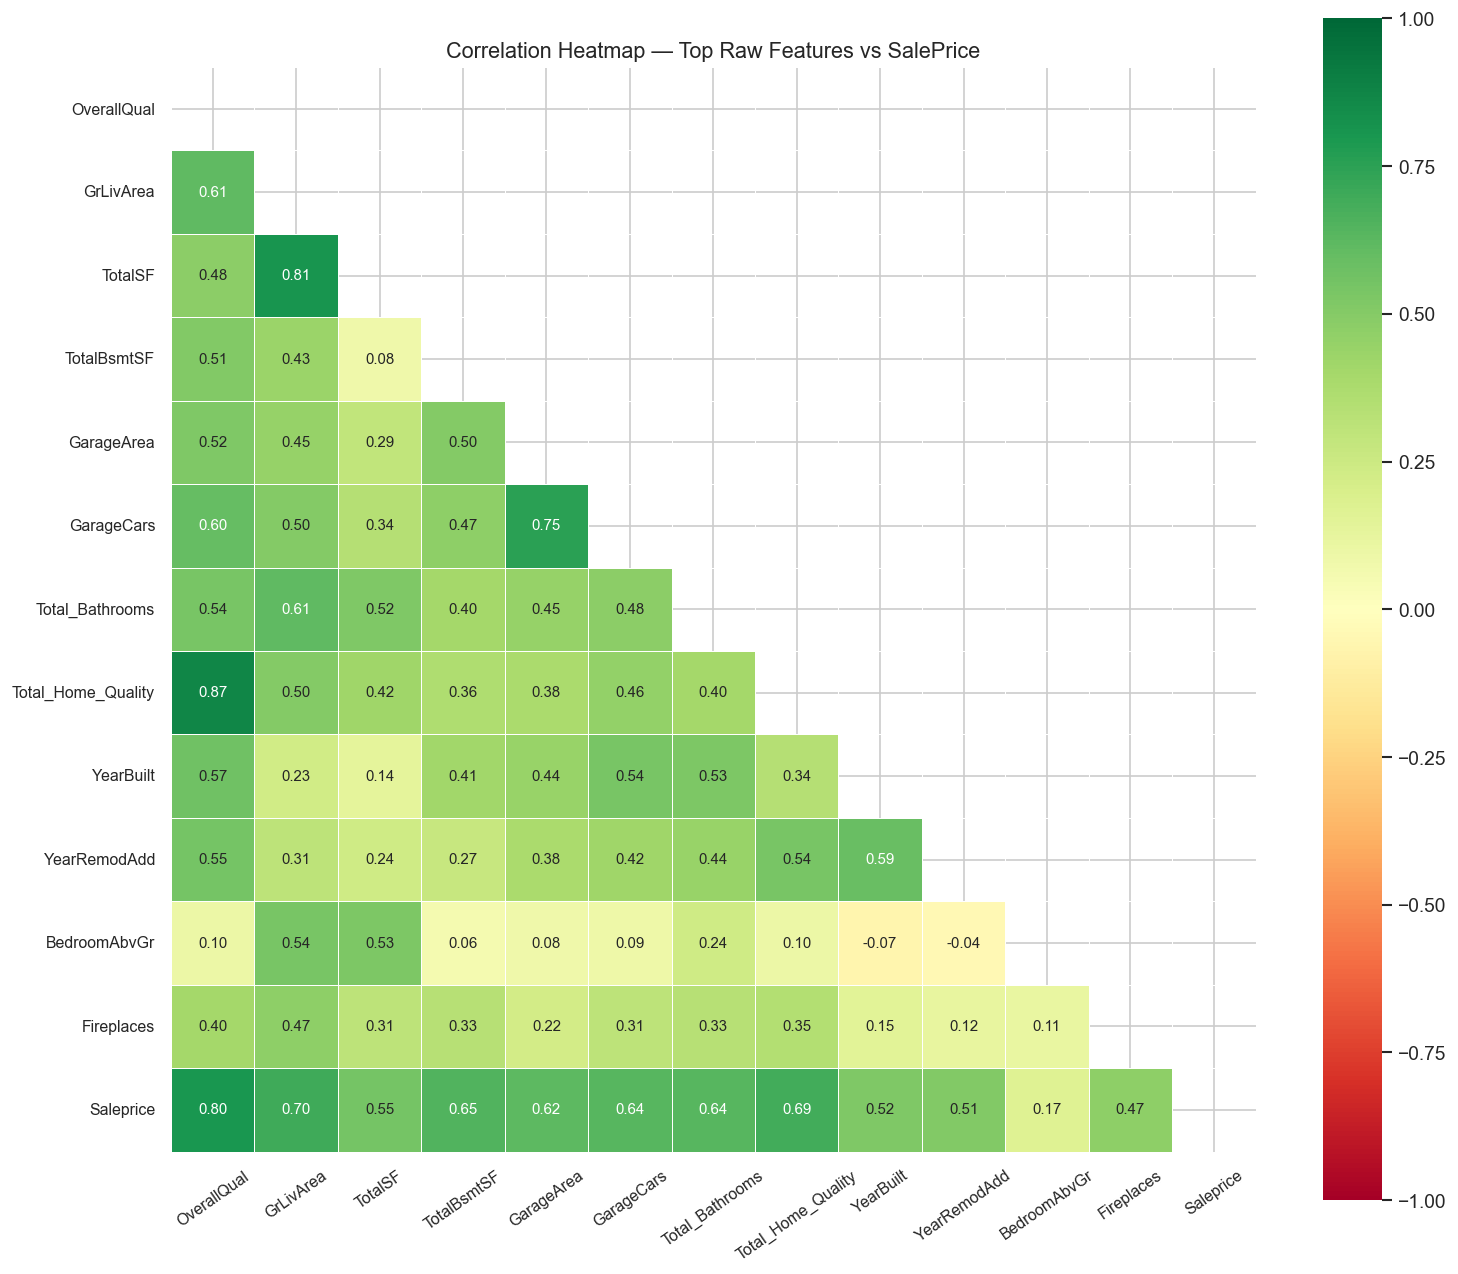


 INSIGHT — Multicollinearity:
   High multicollinearity pairs (|r| ≥ 0.75) — risk of redundancy in models:
      OverallQual               ↔  Total_Home_Quality         r = 0.870
      GrLivArea                 ↔  TotalSF                    r = 0.810
      GarageArea                ↔  GarageCars                 r = 0.750


In [16]:
# Correlation Heatmap (Top 12 Raw Features)

# **Business question:** Are any predictors multicollinear (redundant)?

# Select top interpretable raw features only (no log/squared/OHE)
heat_features = [
    'OverallQual', 'GrLivArea', 'TotalSF', 'TotalBsmtSF',
    'GarageArea', 'GarageCars', 'Total_Bathrooms',
    'Total_Home_Quality', 'YearBuilt', 'YearRemodAdd',
    'BedroomAbvGr', 'Fireplaces', 'Saleprice'
]
heat_features = [c for c in heat_features if c in df.columns]

corr_matrix = df[heat_features].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap — Top Raw Features vs SalePrice', fontsize=13)
ax.tick_params(axis='x', rotation=35, labelsize=9.5)
ax.tick_params(axis='y', rotation=0, labelsize=9.5)

plt.tight_layout()
save('03_10_correlation_heatmap.png')
plt.show()

# Find high multicollinearity pairs
print()
print(' INSIGHT — Multicollinearity:')
pairs = []
for i in range(len(heat_features)):
    for j in range(i+1, len(heat_features)):
        f1, f2 = heat_features[i], heat_features[j]
        if f1 == 'Saleprice' or f2 == 'Saleprice':
            continue
        r = corr_matrix.loc[f1, f2]
        if abs(r) >= 0.75:
            pairs.append((f1, f2, r))

if pairs:
    print('   High multicollinearity pairs (|r| ≥ 0.75) — risk of redundancy in models:')
    for f1, f2, r in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'      {f1:<25} ↔  {f2:<25}  r = {r:.3f}')
else:
    print('   No pairs above |r| ≥ 0.75 among selected features.')

---
## Section 13 — EDA Summary for Report Section 8

In [17]:
# EDA Summary for Report Section 8
print('=' * 65)
print('EDA SUMMARY  —  For Report Section 8')
print('=' * 65)

print(f"""
DATASET PROFILE
  Rows          : {df.shape[0]:,}
  Sale years    : 2006–2010 (Ames, Iowa)
  Neighbourhoods: {df['Neighborhood'].nunique() if 'Neighborhood' in df.columns else 25}

TREND ANALYSIS
  Median price fell from $164K (2006) to $155K (2010) — a $9K drop.
  The 2008–09 financial crisis caused suppressed sales volumes and price stagnation.
  2010 shows both lower price and lower volume (partial year data).

COMPARISON ANALYSIS
  Neighbourhood: Price varies ~3× from cheapest to most expensive area.
  Quality: OverallQual 10 homes are ~3.5× pricier than quality 1–3 homes.
  Building type: Single-family and townhouse end-units command the highest prices.

DISTRIBUTION ANALYSIS
  SalePrice is right-skewed (skew = 1.88) — log transform recommended for modelling.
  GrLivArea and TotalSF are also right-skewed — a few very large homes exist.
  YearBuilt peaks in 1950s and again in 2000s — two major construction eras.

CORRELATION ANALYSIS
  OverallQual  r = 0.796  (strongest predictor)
  GrLivArea    r = 0.704
  TotalSF      r = 0.65+
  GarageArea   r = 0.62+
  All top features positively correlated — no strong negative drivers in top 15.
  Multicollinearity: GrLivArea & TotalSF are highly correlated — use one in models.

PRICE SEGMENTS
  Low (<$130K)       : affordable, smaller homes, older builds, quality 4–5
  Mid ($130K–$214K)  : market core (~50% of homes), average quality 6
  High ($214K–$466K) : premium, quality 7–8, larger and newer
  Luxury (>$466K)    : top-tier, quality 9–10, largest homes in best neighbourhoods
""")

# Final output checklist
charts = [
    '03_01_saleprice_distribution.png',
    '03_02_price_trend_2006_2010.png',
    '03_03_price_by_neighbourhood.png',
    '03_04_price_by_quality.png',
    '03_05_price_by_building_type.png',
    '03_06_feature_distributions.png',
    '03_07_top15_correlations.png',
    '03_08_scatter_size_vs_price.png',
    '03_09_price_segmentation.png',
    '03_10_correlation_heatmap.png',
]

print('\nOUTPUT CHARTS CHECKLIST:')
for chart in charts:
    path = f'{SCREENSHOTS}/{chart}'
    exists = os.path.exists(path)
    size = f'({os.path.getsize(path)/1024:.0f} KB)' if exists else ''
    status = '' if exists else ' NOT FOUND'
    print(f'  {status}  {chart:<50} {size}')

print(f'\n  EDA complete. Next → notebooks/04_statistical_analysis.ipynb')

EDA SUMMARY  —  For Report Section 8

DATASET PROFILE
  Rows          : 1,458
  Sale years    : 2006–2010 (Ames, Iowa)
  Neighbourhoods: 22

TREND ANALYSIS
  Median price fell from $164K (2006) to $155K (2010) — a $9K drop.
  The 2008–09 financial crisis caused suppressed sales volumes and price stagnation.
  2010 shows both lower price and lower volume (partial year data).

COMPARISON ANALYSIS
  Neighbourhood: Price varies ~3× from cheapest to most expensive area.
  Quality: OverallQual 10 homes are ~3.5× pricier than quality 1–3 homes.
  Building type: Single-family and townhouse end-units command the highest prices.

DISTRIBUTION ANALYSIS
  SalePrice is right-skewed (skew = 1.88) — log transform recommended for modelling.
  GrLivArea and TotalSF are also right-skewed — a few very large homes exist.
  YearBuilt peaks in 1950s and again in 2000s — two major construction eras.

CORRELATION ANALYSIS
  OverallQual  r = 0.796  (strongest predictor)
  GrLivArea    r = 0.704
  TotalSF      